In [198]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
import time

$X[k] = \sum_{n=0}^{N-1} x[n]e^{-i2\pi \frac{k}{N}n}$ - the DFT

$x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X_{k}e^{\frac{i2\pi kn}{N}}$ - the inverse DFT

where
* N is the number of samples.
* n is the current sample (index). 
* k is the current frequency (index).
* x[n] is the signal’s value at n.
* X[k] is the DFT at n.

# Q1 b

In [267]:
def func(x):
    return np.exp(-50*(x-0.5)**2)

def func_analytic(k):
    return np.sqrt(np.pi/50)*np.exp(-0.5*1j*k-(k**2/200))

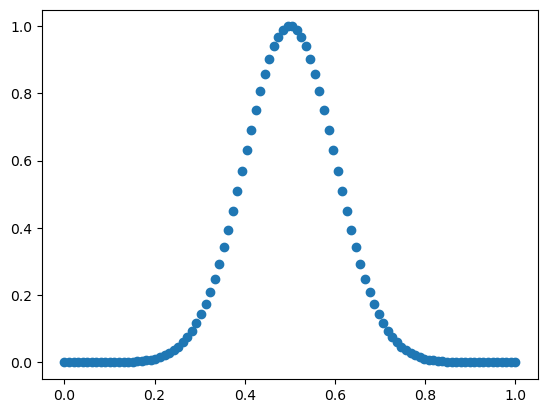

In [224]:
x = np.linspace(0,1,100)
plt.scatter(x,func(x))

Part b is saying to do the forward DFT for three values of N on the equation that I did analytically, then plot the results of these next to my analytical fourier transform.

When it says to invert k-space results, it means to do the inverse fourier transform.

In [324]:
def func_sampled(N):
    x = np.arange(N)/N #need to discretize the function
    
    return np.exp(-50*(x - 0.5)**2)

def DFT(inputfunc,N):
    X=np.zeros(N,dtype="complex") #keep the complex parts too
    for k in range(0,N): #by nature of python this should be N-1
        for n in range(0,N):
            X[k] += inputfunc[n]*(np.exp((-1j*2*np.pi*n*k)/N))
    return X

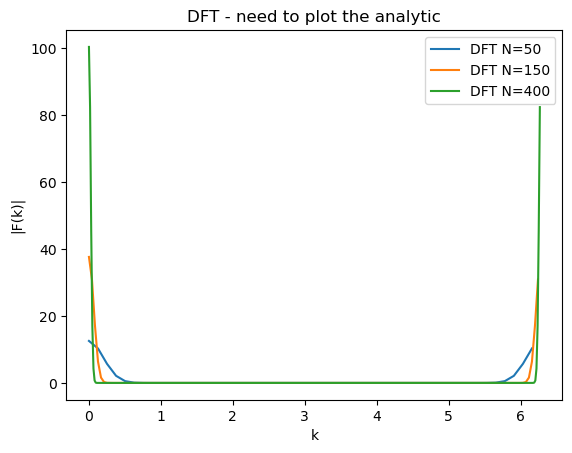

In [331]:
for N in [50, 150, 400]:
    fx = func_sampled(N)
    X = DFT(fx, N)

    k = 2*np.pi * np.arange(N)/N
    plt.plot(k, np.abs(X), label=f"DFT N={N}")


plt.xlabel("k")
plt.ylabel("|F(k)|")
plt.legend()
plt.title("DFT - need to plot the analytic")
plt.show()

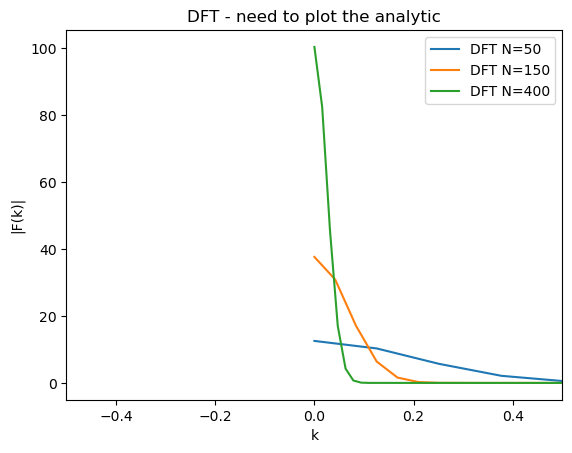

In [332]:
for N in [50, 150, 400]:
    fx = func_sampled(N)
    X = DFT(fx, N)
    k = 2*np.pi * np.arange(N)/N
    plt.plot(k, np.abs(X), label=f"DFT N={N}")


plt.xlim(-.5,.5)
plt.xlabel("k")
plt.ylabel("|F(k)|")
plt.legend()
plt.title("DFT - need to plot the analytic")
plt.show()

In [219]:
#now I need to do the inverse of these:
def IDFT(inputfunc,N):
    x = np.zeros(N,dtype="complex") #keep the complex parts too
    for n in range(0,N): #by nature of python this should be N-1
        for k in range(0,N):
            x[n] += inputfunc[k] * (np.exp((1j*2*np.pi*n*k)/N))
    return x/N

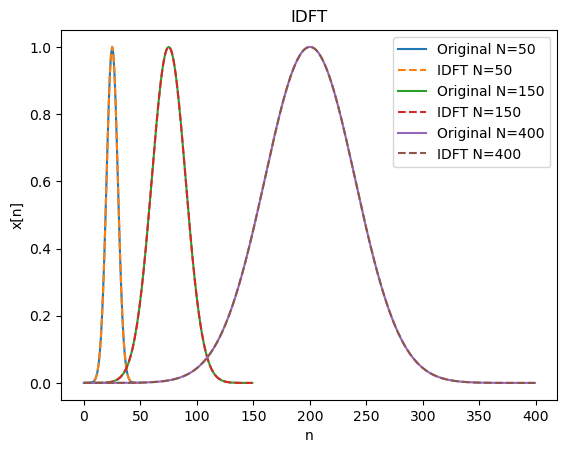

In [246]:
for N in [50, 150, 400]:
    x = func_sampled(N)
    X = DFT(x, N)
    x_idft = IDFT(X, N)

    n = np.arange(N)

    plt.plot(n, x, label=f"Original N={N}")
    plt.plot(n, x_idft, '--', label=f"IDFT N={N}")

plt.legend()
plt.title("IDFT")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.show()

# Q1 c

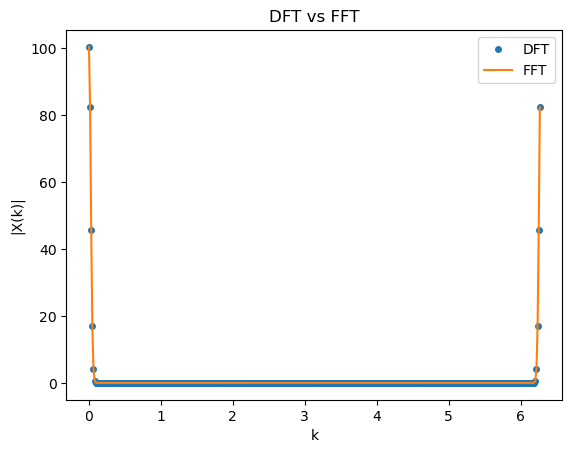

In [183]:
N = 400  
x = func_sampled(N) #discretizing function given

X_dft = DFT(x, N) #my DFT
X_fft = fft(x) #Scipy fft
k = 2*np.pi * np.arange(N)/N #k vals/frequency vals to plot against

plt.plot(k, np.abs(X_dft), 'o', label="DFT", markersize=4)
plt.plot(k, np.abs(X_fft), '-', label="FFT")
plt.xlabel("k")
plt.ylabel("|X(k)|")
plt.legend()
plt.title("DFT vs FFT")
plt.show()

In [184]:
#timing stuff

# Q2 a

In [192]:
def heat(N):
    x = np.arange(N)/N 
    return np.exp(-50*(x-0.5)**2)

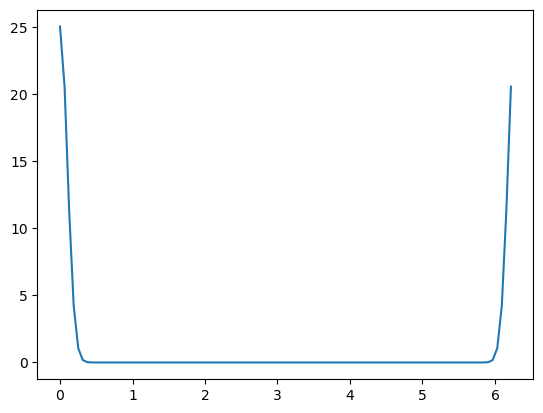

In [193]:
N = 100
x = heat(N) 
X = DFT(x, N)
k = 2*np.pi * np.arange(N)/N #vals to plot against (should be in k space)

plt.plot(k, np.abs(X), label=f"N={N}")


In [196]:
#Runge-kutta
def heat_ode(a,k,uhat):
    return -a*k**2*uhat
    
def RK4(ki, kf, yi, steps=100):
    '''
    xi = initial x, xf = final x, yi = initial y, steps = number of steps to go for loop (default = 100), xprnt is a flag if one wants to
    print out the step size, h (default = False).    '''

    x_vals = [xi]
    y_vals = [yi]

    a = 0.005
    T = 5
    dt = 0.001

    h = T/dt
        
    for i in range(T):
        k1 = func(a,ki,yi)
        k2 = func(a,ki+(h/2), yi+k1*(h/2))
        k3 = func(xi+(h/2),yi+k2*(h/2))
        k4 = func(xi+h,yi+k3*h)
        
        y_new = yi + (h/6)*(k1+2*k2+2*k3+k4)
        x_new = xi + h

        yi = y_new
        xi = x_new

        x_vals.append(xi)
        y_vals.append(yi)

    return np.array(x_vals), np.array(y_vals), h

# Q2 b